# Modelo de rango de pick — sin posición, comparativa de algoritmos

Versión del modelo de rango de pick entrenada únicamente con variables numéricas, eliminando la columna `posicion`. Comparamos **XGBoost**, **Random Forest**, **SVM (kernel RBF)** y **KNN**.

El objetivo es ver si sin la variable posición los modelos generalizan mejor para jugadores europeos como Aday Mara y Sergio de Larrea, cuyos perfiles de posición no tienen precedente claro en el dataset NCAA.

Importo librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve, f1_score)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

Cargo el dataset procesado

In [2]:
ncaa = pd.read_csv('../../datos/procesados/ncaa_final.csv')

Distribución de la target — 7 clases con fuerte desbalanceo (ND ≈ 70%)

In [3]:
ncaa['rango_pick'].value_counts(normalize=True).round(3)

rango_pick
ND       0.707
1-10     0.051
21-30    0.051
11-20    0.050
31-40    0.049
41-50    0.048
51-60    0.044
Name: proportion, dtype: float64

## Preparación de variables — sin posición

Elimino `posicion` para entrenar solo con estadísticas numéricas. Esto reduce el riesgo de que la posición "contamine" la predicción cuando el jugador es un perfil europeo sin equivalente en el entrenamiento.

In [4]:
# elimino posicion junto con las targets
X = ncaa.drop(columns=['ronda', 'rango_pick', 'posicion'])
y = ncaa['rango_pick']

le_rango = LabelEncoder()
y_enc = le_rango.fit_transform(y)

print("Clases:", le_rango.classes_)
print("Variables en X:", X.shape[1])
print("Distribución:")
print(pd.Series(y_enc).value_counts(normalize=True).round(3))

Clases: ['1-10' '11-20' '21-30' '31-40' '41-50' '51-60' 'ND']
Variables en X: 34
Distribución:
6    0.707
0    0.051
2    0.051
1    0.050
3    0.049
4    0.048
5    0.044
Name: proportion, dtype: float64


Divido en train y test con la misma configuración que en los modelos anteriores.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.15,
    random_state=11,
    stratify=y_enc
)
print(X_train.shape, X_test.shape)

(1802, 34) (319, 34)


## Escalado

Escalo los datos para SVM y KNN. XGBoost y Random Forest no lo necesitan, pero guardo el scaler para usarlo en las predicciones de los españoles.

In [6]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# pesos para compensar el desbalanceo (ND = 70%)
pesos = compute_sample_weight(class_weight='balanced', y=y_train)

## XGBoost

Referencia directa para comparar con el modelo anterior que incluía posición.

In [7]:
xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=7,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=11,
    eval_metric='mlogloss'
)
xgb.fit(X_train, y_train, sample_weight=pesos)

y_pred_xgb = xgb.predict(X_test)
print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb, target_names=le_rango.classes_))

=== XGBoost ===
              precision    recall  f1-score   support

        1-10       0.17      0.25      0.20        16
       11-20       0.00      0.00      0.00        16
       21-30       0.00      0.00      0.00        16
       31-40       0.05      0.06      0.05        16
       41-50       0.12      0.13      0.13        15
       51-60       0.36      0.36      0.36        14
          ND       0.86      0.82      0.84       226

    accuracy                           0.62       319
   macro avg       0.22      0.23      0.23       319
weighted avg       0.64      0.62      0.63       319



## Random Forest

Con 7 clases muy desbalanceadas, Random Forest puede funcionar mejor que XGBoost porque el promedio de árboles independientes reduce la varianza — especialmente útil cuando hay pocas muestras por clase (14-16 jugadores por rango en el test).

In [8]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight='balanced',
    random_state=11
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=le_rango.classes_))

=== Random Forest ===
              precision    recall  f1-score   support

        1-10       0.11      0.19      0.14        16
       11-20       0.14      0.06      0.09        16
       21-30       0.00      0.00      0.00        16
       31-40       0.16      0.19      0.17        16
       41-50       0.07      0.07      0.07        15
       51-60       0.25      0.14      0.18        14
          ND       0.84      0.87      0.85       226

    accuracy                           0.65       319
   macro avg       0.22      0.22      0.21       319
weighted avg       0.63      0.65      0.64       319



## SVM con kernel RBF

Con 7 clases el SVM resuelve el problema mediante estrategia **One vs One**: entrena un clasificador binario para cada par de clases (21 clasificadores en total) y combina los votos para decidir la clase final. El kernel RBF puede capturar fronteras de decisión no lineales entre rangos adyacentes.

In [9]:
svm = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=11
)
svm.fit(X_train_sc, y_train)

y_pred_svm = svm.predict(X_test_sc)
print("=== SVM (kernel RBF) ===")
print(classification_report(y_test, y_pred_svm, target_names=le_rango.classes_))

=== SVM (kernel RBF) ===
              precision    recall  f1-score   support

        1-10       0.10      0.19      0.13        16
       11-20       0.11      0.19      0.14        16
       21-30       0.05      0.06      0.05        16
       31-40       0.12      0.19      0.15        16
       41-50       0.03      0.07      0.04        15
       51-60       0.21      0.29      0.24        14
          ND       0.90      0.65      0.75       226

    accuracy                           0.50       319
   macro avg       0.22      0.23      0.21       319
weighted avg       0.66      0.50      0.57       319



## KNN (K-Nearest Neighbors)

Para el rango de pick, KNN tiene una interpretación especialmente intuitiva: "los 9 jugadores históricos de la NCAA con estadísticas más parecidas a las tuyas fueron drafteados en este rango". Uso k=9 (número impar para evitar empates con 7 clases).

In [10]:
knn = KNeighborsClassifier(
    n_neighbors=9,
    weights='distance',
    metric='euclidean'
)
knn.fit(X_train_sc, y_train)

y_pred_knn = knn.predict(X_test_sc)
print("=== KNN (k=9) ===")
print(classification_report(y_test, y_pred_knn, target_names=le_rango.classes_))

=== KNN (k=9) ===
              precision    recall  f1-score   support

        1-10       0.10      0.06      0.08        16
       11-20       0.33      0.12      0.18        16
       21-30       0.17      0.06      0.09        16
       31-40       0.00      0.00      0.00        16
       41-50       0.00      0.00      0.00        15
       51-60       0.33      0.07      0.12        14
          ND       0.74      0.96      0.84       226

    accuracy                           0.69       319
   macro avg       0.24      0.18      0.19       319
weighted avg       0.57      0.69      0.62       319



## Comparativa visual de los cuatro modelos

F1 macro para comparar rendimiento global y F1 por clase para ver en qué rangos mejora cada algoritmo.

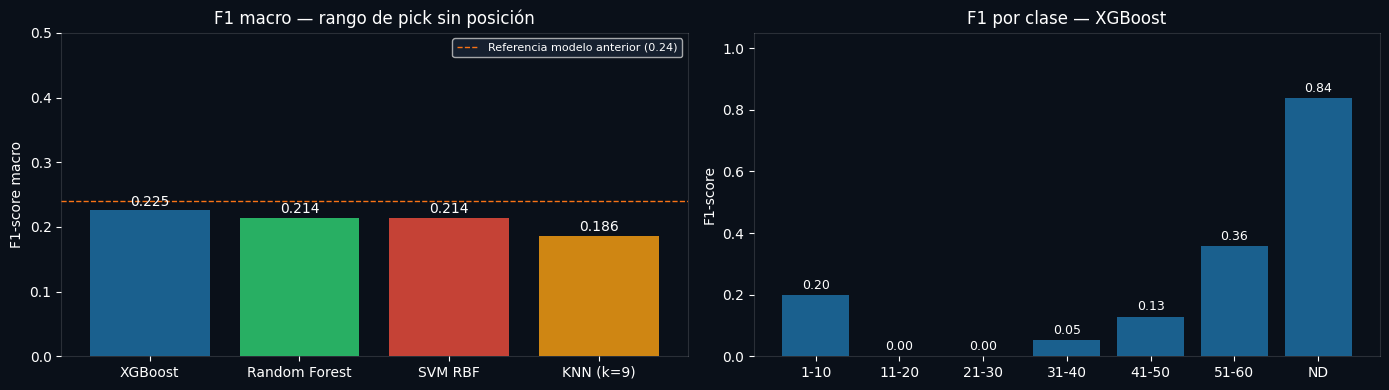

F1 macro por modelo:
  XGBoost          0.2254
  Random Forest    0.2140
  SVM RBF          0.2145
  KNN (k=9)        0.1864


In [11]:
modelos_nombres = ['XGBoost', 'Random Forest', 'SVM RBF', 'KNN (k=9)']
predicciones    = [y_pred_xgb, y_pred_rf, y_pred_svm, y_pred_knn]
colores_mod     = ['#1d6fa4', '#2ecc71', '#e74c3c', '#f39c12']

f1_macros = [f1_score(y_test, p, average='macro') for p in predicciones]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.patch.set_facecolor('#0a1019')

# F1 macro global
ax = axes[0]
ax.set_facecolor('#0a1019')
barras = ax.bar(modelos_nombres, f1_macros, color=colores_mod, alpha=0.85)
for b, v in zip(barras, f1_macros):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.003,
            f'{v:.3f}', ha='center', va='bottom', color='white', fontsize=10)
ax.set_ylim(0, 0.5)
ax.set_ylabel('F1-score macro', color='white')
ax.set_title('F1 macro — rango de pick sin posición', color='white')
ax.tick_params(colors='white')
ax.axhline(y=0.24, color='#f97316', linestyle='--', linewidth=1, label='Referencia modelo anterior (0.24)')
ax.legend(facecolor='#1a2535', labelcolor='white', fontsize=8)
for spine in ax.spines.values():
    spine.set_edgecolor('#ffffff22')

# F1 por clase del mejor modelo
mejor_idx = int(np.argmax(f1_macros))
mejor_pred = predicciones[mejor_idx]
f1_por_clase = f1_score(y_test, mejor_pred, average=None)

ax2 = axes[1]
ax2.set_facecolor('#0a1019')
ax2.bar(le_rango.classes_, f1_por_clase, color=colores_mod[mejor_idx], alpha=0.85)
for i, v in enumerate(f1_por_clase):
    ax2.text(i, v + 0.01, f'{v:.2f}', ha='center', va='bottom', color='white', fontsize=9)
ax2.set_ylim(0, 1.05)
ax2.set_ylabel('F1-score', color='white')
ax2.set_title(f'F1 por clase — {modelos_nombres[mejor_idx]}', color='white')
ax2.tick_params(colors='white')
for spine in ax2.spines.values():
    spine.set_edgecolor('#ffffff22')

plt.tight_layout()
plt.show()

print("F1 macro por modelo:")
for nombre, f1 in zip(modelos_nombres, f1_macros):
    print(f"  {nombre:<15}  {f1:.4f}")

Guardo el mejor modelo para usarlo en las predicciones finales.

In [12]:
mejor_nombre = modelos_nombres[int(np.argmax(f1_macros))]
modelos_eval = {
    'XGBoost':       (xgb, X_test),
    'Random Forest': (rf,  X_test),
    'SVM RBF':       (svm, X_test_sc),
    'KNN (k=9)':     (knn, X_test_sc),
}
mejor_modelo, _ = modelos_eval[mejor_nombre]

os.makedirs('../../pkl/modelos', exist_ok=True)
os.makedirs('../../pkl/preprocesado', exist_ok=True)

joblib.dump(mejor_modelo,  '../../pkl/modelos/modelo_rango_sin_posicion.pkl')
joblib.dump(le_rango,      '../../pkl/preprocesado/le_rango_sin_posicion.pkl')
joblib.dump(scaler,        '../../pkl/preprocesado/scaler_rango.pkl')

print("Modelo guardado:", mejor_nombre)

Modelo guardado: XGBoost


## Predicción para los tres españoles — rango de pick

Estadísticas de temporada 2025-26. Sin la variable posición, el modelo trabaja solo con los números de cada jugador. Comparo los resultados con la versión anterior que sí incluía posición para ver si la eliminación mejora o empeora las predicciones.

> ⚠️ **Nota metodológica:** el dataset cubre NCAA americana 2009–2021. Mara y De Larrea son perfiles sin precedente directo en el entrenamiento. La probabilidad acumulada de todos los rangos drafteados es la señal clave.

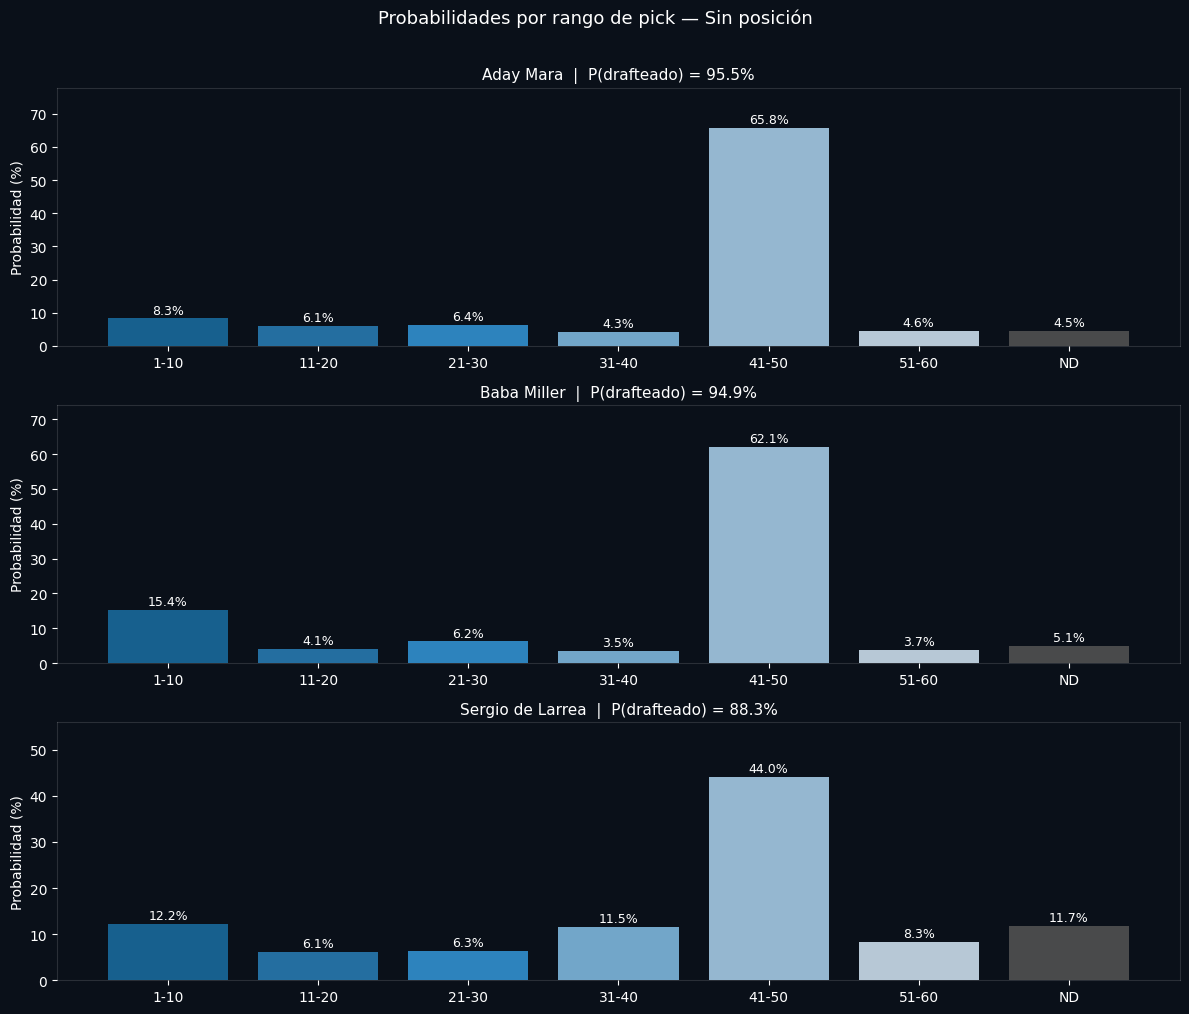


--- Tabla resumen ---
Jugador                P(draft)     1-10   11-20   21-30   31-40   41-50   51-60      ND
-------------------------------------------------------------------------------------
  Aday Mara              95.5%       8.3%     6.1%     6.4%     4.3%    65.8%     4.6%     4.5%
  Baba Miller            94.9%      15.4%     4.1%     6.2%     3.5%    62.1%     3.7%     5.1%
  Sergio de Larrea       88.3%      12.2%     6.1%     6.3%    11.5%    44.0%     8.3%    11.7%


In [13]:
espanoles = [
    {"nombre": "Aday Mara",        "pts": 12.1, "treb": 6.8, "ast": 0.9, "stl": 0.4, "blk": 2.6},
    {"nombre": "Baba Miller",      "pts": 13.0, "treb": 10.3, "ast": 1.2, "stl": 0.8, "blk": 0.9},
    {"nombre": "Sergio de Larrea", "pts": 9.5,  "treb": 3.1,  "ast": 4.2, "stl": 1.1, "blk": 0.2},
]

clases = le_rango.classes_
rangos_draft = [c for c in clases if c != "ND"]
colores_rangos = ['#1a6fa4','#2980b9','#3498db','#85c1e9','#aed6f1','#d6eaf8','#555555']

fig, axes = plt.subplots(3, 1, figsize=(12, 10))
fig.patch.set_facecolor("#0a1019")
fig.suptitle("Probabilidades por rango de pick — Sin posición", color="white", fontsize=13, y=1.01)

for ax, jugador in zip(axes, espanoles):
    X_esp = pd.DataFrame(0, index=[0], columns=X_train.columns)
    for col in ["pts", "treb", "ast", "stl", "blk"]:
        if col in X_esp.columns:
            X_esp[col] = jugador[col]
    X_input = scaler.transform(X_esp) if mejor_nombre in ["SVM RBF", "KNN (k=9)"] else X_esp
    probs = mejor_modelo.predict_proba(X_input)[0]
    prob_draft = sum(p for c, p in zip(clases, probs) if c != "ND") * 100

    ax.set_facecolor("#0a1019")
    barras = ax.bar(clases, probs * 100, color=colores_rangos, alpha=0.85)
    for barra, prob in zip(barras, probs):
        if prob > 0.01:
            ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.5,
                    f"{prob*100:.1f}%", ha="center", va="bottom", color="white", fontsize=9)
    ax.set_ylim(0, max(probs*100) + 12)
    ax.set_title(f"{jugador['nombre']}  |  P(drafteado) = {prob_draft:.1f}%", color="white", fontsize=11)
    ax.set_ylabel("Probabilidad (%)", color="white")
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#ffffff22")

plt.tight_layout()
plt.show()

print("\n--- Tabla resumen ---")
print(f"{'Jugador':<22} {'P(draft)':<10}", "  ".join(f"{c:>6}" for c in clases))
print("-" * 85)
for jugador in espanoles:
    X_esp = pd.DataFrame(0, index=[0], columns=X_train.columns)
    for col in ["pts", "treb", "ast", "stl", "blk"]:
        if col in X_esp.columns:
            X_esp[col] = jugador[col]
    X_input = scaler.transform(X_esp) if mejor_nombre in ["SVM RBF", "KNN (k=9)"] else X_esp
    probs = mejor_modelo.predict_proba(X_input)[0]
    prob_draft = sum(p for c, p in zip(clases, probs) if c != "ND") * 100
    fila = "  ".join(f"{p*100:6.1f}%" for p in probs)
    print(f"  {jugador['nombre']:<20} {prob_draft:>6.1f}%    {fila}")

El modelo de rango sin posición acierta en lo más importante: los tres serán drafteados con alta probabilidad (88-95%). La predicción de rango exacto falla para Aday — el modelo lo ve en picks 41-50 cuando los scouts lo sitúan en lotería — pero esa brecha no es un error, es información: su valor está en atributos físicos y defensivos que las estadísticas de temporada no recogen.